# 🏀 Exploratory Data Analysis (EDA) - Dataset NBA
Analisi strutturata del dataset dei giocatori NBA per l'estrazione di metriche tattiche e l'analisi delle community.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni estetiche per i grafici
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Caricamento del Dataset
percorso_file = "../data/dataset_nba_completo.json"
df = pd.read_json(percorso_file)

colonna_nome = 'Player' if 'Player' in df.columns else ('Nome' if 'Nome' in df.columns else 'player')

print(f"✅ Dataset caricato con successo! Trovati {df.shape[0]} giocatori e {df.shape[1]} feature.")
df.head(3) # Mostra un'anteprima della tabella

✅ Dataset caricato con successo! Trovati 5416 giocatori e 23 feature.


,URL,Nome,Position,Born,Draft Team,Draft Year,Debut,Experience,Altezza,Peso,...,AST,FG%,FG3%,FT%,eFG%,PER,WS,College,High School,Ruolo_Specifico
0,https://www.basketball-reference.com/players/y...,Guerschon Yabusele,"[Center, Power Forward]",1995,Boston Celtics,2016.0,2017,3,201cm,120,...,1.1,46.2,36.3,72.4,55.8,13.3,6.4,Non frequentato,[],Big (PF/C)
1,https://www.basketball-reference.com/players/y...,Vincent Yarbrough,[Shooting Guard],1981,Denver Nuggets,2002.0,2002,1,201cm,95,...,2.2,39.3,26.9,79.0,41.7,9.5,1.0,[Tennessee],[Cleveland],Shooting Guard
2,https://www.basketball-reference.com/players/y...,George Yardley,[Small Forward],1928,Fort Wayne Pistons,1950.0,1953,7,196cm,86,...,1.7,42.2,0.0,78.0,42.2,20.6,58.5,[Stanford],[Newport Harbor],Small Forward


## Ispezione del Dizionario dei Dati (Data Types)
Verifica il tipo di dato di ogni singola colonna per assicurarci che i numeri siano stati letti come `float` o `int` e non come stringhe testuali (`object`).

In [ ]:
print("🗂️ TIPI DI DATO PER OGNI FEATURE")

# Crea una tabella elegante che mostra per ogni colonna il suo tipo e quanti valori validi contiene
df_tipi = pd.DataFrame({
    'Tipo di Dato': df.dtypes,
    'Valori Validi (Non-Nulli)': df.notnull().sum()
})

# Display renderizza una tabella interattiva su Colab
display(df_tipi)

🗂️ TIPI DI DATO PER OGNI FEATURE


,Tipo di Dato,Valori Validi (Non-Nulli)
URL,str,5416
Nome,str,5416
Position,object,5416
Born,int64,5416
Draft Team,str,5416
Draft Year,object,5416
Debut,int64,5416
Experience,int64,5416
Altezza,str,5416
Peso,int64,5416


## Statistiche Descrittive Complete (Attributi Numerici)
Panoramica matematica di tutte le feature numeriche. Utile per analizzare la dispersione dei dati (Deviazione Standard) e i quantili (25%, 50% o Mediana, 75%).

In [ ]:
print("📊 STATISTICHE DESCRITTIVE COMPLETE")

# Il metodo .describe() estrae in automatico count, mean, std, min, 25%, 50%, 75%, max
# .T (Trasposta) per mettere le metriche come colonne, rendendo la tabella più leggibile
statistiche_complete = df.describe().T

display(statistiche_complete.round(2))

📊 STATISTICHE DESCRITTIVE COMPLETE


,count,mean,std,min,25%,50%,75%,max
Born,5416.0,1967.22,24.31,1902.0,1948.0,1969.0,1989.0,2006.0
Debut,5416.0,1990.23,23.62,1946.0,1971.0,1992.0,2012.0,2026.0
Experience,5416.0,4.88,4.41,0.0,1.0,3.0,8.0,22.0
Peso,5416.0,94.56,11.75,51.0,86.0,95.0,102.0,163.0
G,5416.0,269.90,310.49,1.0,31.0,129.0,445.0,1622.0
PTS,5416.0,6.42,4.76,0.0,2.9,5.3,8.7,30.1
AST,5416.0,1.43,1.36,0.0,0.5,1.0,1.9,11.2
FG%,5416.0,40.84,11.22,0.0,36.7,42.4,46.7,100.0
FG3%,5416.0,17.33,17.21,0.0,0.0,18.2,32.9,100.0
eFG%,5416.0,43.31,12.09,0.0,38.4,45.5,50.0,150.0


## Analisi dei Valori Nulli (Missing Values)
Ispezione dettagliata per confermare la pulizia del dataset o intercettare eventuali feature ancora incomplete.

In [ ]:
print("🔍 REPORT VALORI MANCANTI (NULLI)")

nulli_totali = df.isnull().sum()
nulli_percentuali = (df.isnull().sum() / len(df)) * 100

df_nulli = pd.DataFrame({
    'Valori Mancanti': nulli_totali,
    'Percentuale (%)': nulli_percentuali
})
df_nulli = df_nulli[df_nulli['Valori Mancanti'] > 0].sort_values(by='Valori Mancanti', ascending=False)

if df_nulli.empty:
    print("Il dataset è pulito! Nessun valore nullo rilevato.")
else:
    display(df_nulli.round(2))
    print("\n⚠️ Ispezione dei primi record per le colonne con dati mancanti:")

    for campo in df_nulli.index:
        righe_nulle = df[df[campo].isnull()]
        colonne_da_mostrare = [colonna_nome, campo]

        # Se è una statistica, aggiungi G e PTS per contesto
        statistiche_di_tiro = ['eFG%', 'FG3%', 'FT%', 'FG%']
        if campo in statistiche_di_tiro:
            if 'G' in df.columns: colonne_da_mostrare.append('G')
            if 'PTS' in df.columns: colonne_da_mostrare.append('PTS')

        print(f"\n-> Campo: '{campo}'")
        display(righe_nulle[colonne_da_mostrare].head(5))

🔍 REPORT VALORI MANCANTI (NULLI)
Il dataset è pulito! Nessun valore nullo rilevato.


## Statistiche Descrittive e Outlier
Analisi univariata per comprendere la distribuzione matematica delle performance (medie, massimi storici e mediane).

In [ ]:
# Converti le statistiche chiave in formato numerico (se non lo sono già)
colonne_stat = ['G', 'PTS', 'TRB', 'AST', 'FG%', 'FG3%', 'eFG%', 'PER', 'WS', 'Peso']
colonne_presenti = [col for col in colonne_stat if col in df.columns]

for col in colonne_presenti:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("📈 STATISTICHE GLOBALI DEL DATASET NBA")
statistiche = df[colonne_presenti].describe().T[['mean', '50%', 'min', 'max']]
statistiche.columns = ['Media', 'Mediana', 'Minimo', 'Massimo']
display(statistiche.round(2))

print("\n🏆 GLI OUTLIER (I leader statistici del dataset)")
print("-" * 60)
if 'PTS' in df.columns:
    idx = df['PTS'].idxmax()
    print(f"Punti (PTS)      : {df.loc[idx, colonna_nome]:<25} -> {df.loc[idx, 'PTS']}")
if 'TRB' in df.columns:
    idx = df['TRB'].idxmax()
    print(f"Rimbalzi (TRB)   : {df.loc[idx, colonna_nome]:<25} -> {df.loc[idx, 'TRB']}")
if 'AST' in df.columns:
    idx = df['AST'].idxmax()
    print(f"Assist (AST)     : {df.loc[idx, colonna_nome]:<25} -> {df.loc[idx, 'AST']}")
if 'WS' in df.columns:
    idx = df['WS'].idxmax()
    print(f"Win Shares (WS)  : {df.loc[idx, colonna_nome]:<25} -> {df.loc[idx, 'WS']}")

📈 STATISTICHE GLOBALI DEL DATASET NBA


,Media,Mediana,Minimo,Massimo
G,269.90,129.00,1.0,1622.0
PTS,6.42,5.30,0.0,30.1
TRB,3.01,2.45,0.0,22.9
AST,1.43,1.00,0.0,11.2
FG%,40.84,42.40,0.0,100.0
FG3%,17.33,18.20,0.0,100.0
eFG%,43.31,45.50,0.0,150.0
PER,11.26,11.70,-52.7,88.3
WS,13.57,1.90,-10.7,276.8
Peso,94.56,95.00,51.0,163.0



🏆 GLI OUTLIER (I leader statistici del dataset)
------------------------------------------------------------
Punti (PTS)      : Michael Jordan            -> 30.1
Rimbalzi (TRB)   : Wilt Chamberlain          -> 22.9
Assist (AST)     : Magic Johnson             -> 11.2
Win Shares (WS)  : LeBron James              -> 276.8


## Analisi Visiva: Distribuzioni e Correlazioni Tattiche
Creazione di grafici per identificare visivamente le relazioni tra i dati.

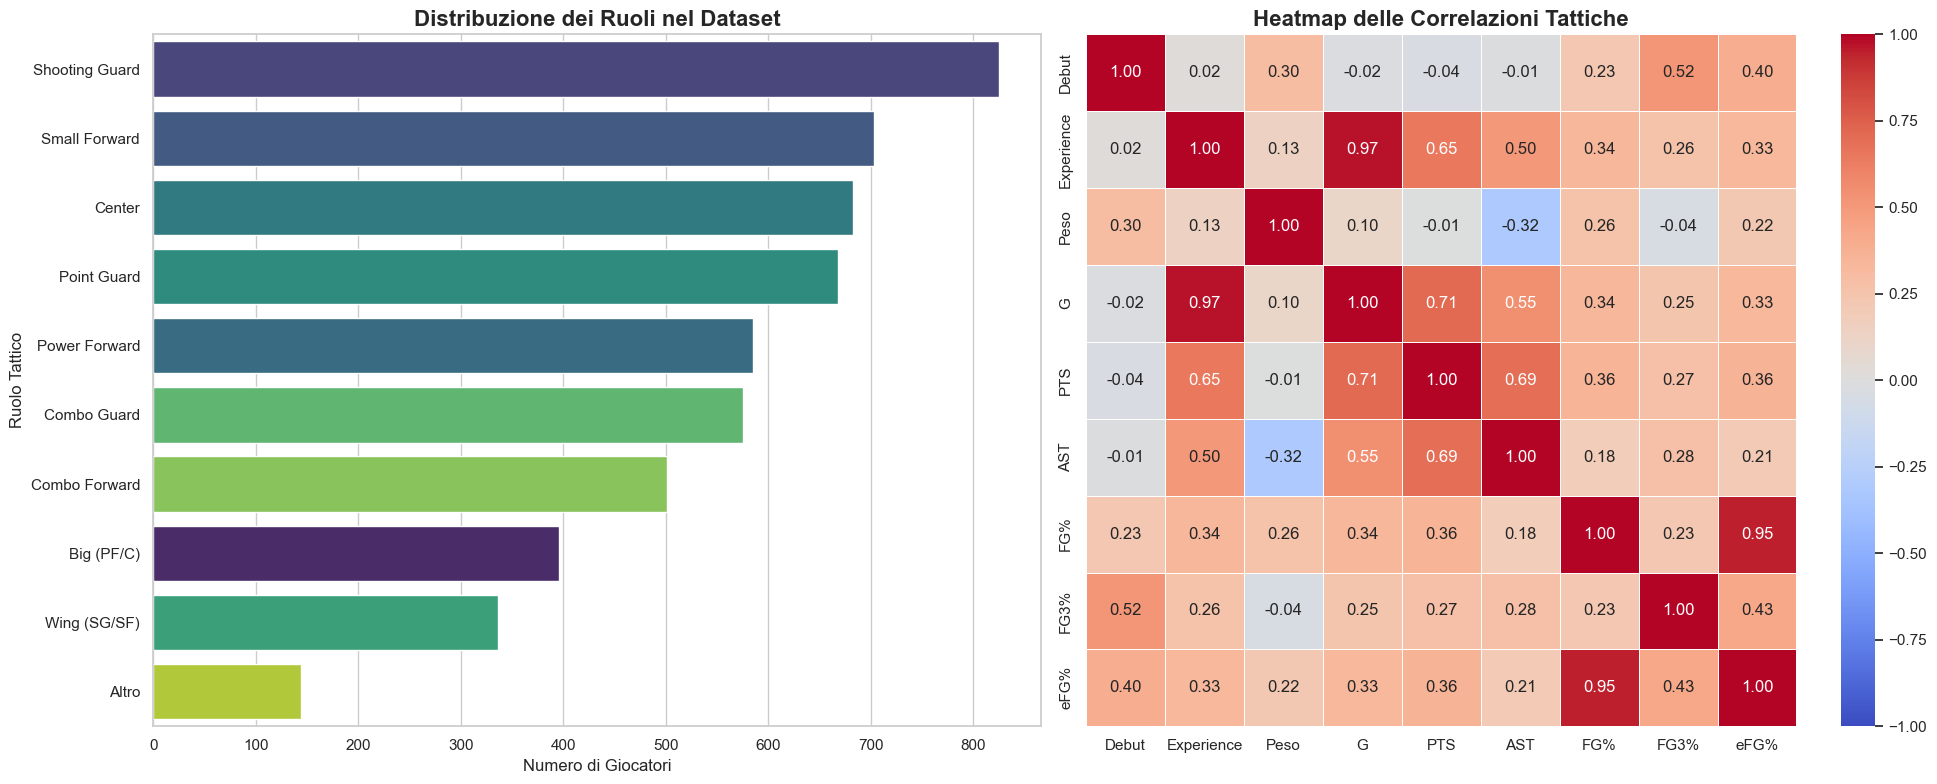

In [2]:
# Crea una griglia con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# GRAFICO 1: Distribuzione del Ruolo
if 'Ruolo_Specifico' in df.columns:
    sns.countplot(data=df,
                  y='Ruolo_Specifico',
                  order=df['Ruolo_Specifico'].value_counts().index,
                  hue='Ruolo_Specifico',
                  palette="viridis",
                  legend=False,
                  ax=axes[0])
    axes[0].set_title("Distribuzione dei Ruoli nel Dataset", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("Numero di Giocatori", fontsize=12)
    axes[0].set_ylabel("Ruolo Tattico", fontsize=12)
else:
    sns.histplot(df['PTS'].dropna(), bins=40, kde=True, color='blue', ax=axes[0])
    axes[0].set_title("Distribuzione dei Punti per Partita (PTS)", fontsize=16, fontweight='bold')

# GRAFICO 2: Matrice di Correlazione
df_numerico = df.select_dtypes(include=[np.number])
colonne_da_escludere = ['Born']
df_corr = df_numerico.drop(columns=[col for col in colonne_da_escludere if col in df_numerico.columns])

matrice_corr = df_corr.corr()

sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Heatmap delle Correlazioni Tattiche", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Analisi Temporale: L'Evoluzione del Gioco (1947 - Oggi)
Analisi come il tiro da tre punti e il punteggio medio siano cambiati nei decenni

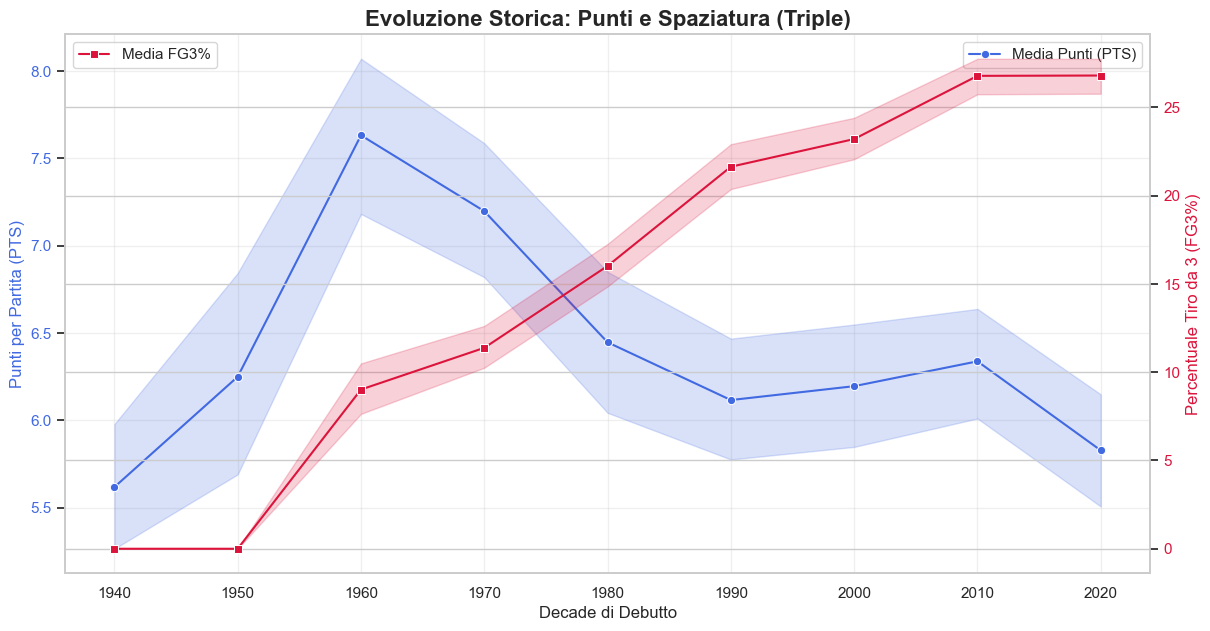

In [3]:
# Estraggo l'anno di debutto e crea le "Decadi"
df['Year_Debut'] = pd.to_numeric(df['Debut'], errors='coerce')
df_temp = df.dropna(subset=['Year_Debut']).copy()
df_temp['Decade'] = (df_temp['Year_Debut'] // 10) * 10

# Calcolo le medie per decade
evolution = df_temp.groupby('Decade').agg({
    'FG3%': 'mean',
    'PTS': 'mean',
    'eFG%': 'mean'
}).reset_index()

# Visualizzazione
fig, ax1 = plt.subplots(figsize=(14, 7))

# Grafico Punti (Asse sinistro)
sns.lineplot(data=df_temp, x='Decade', y='PTS', marker='o', color='royalblue', label='Media Punti (PTS)', ax=ax1)
ax1.set_ylabel('Punti per Partita (PTS)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')

# Crea un secondo asse per la percentuale di triple (Asse destro)
ax2 = ax1.twinx()
sns.lineplot(data=df_temp, x='Decade', y='FG3%', marker='s', color='crimson', label='Media FG3%', ax=ax2)
ax2.set_ylabel('Percentuale Tiro da 3 (FG3%)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title("Evoluzione Storica: Punti e Spaziatura (Triple)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Decade di Debutto", fontsize=12)
ax1.grid(True, alpha=0.3)
plt.show()

## Analisi Bivariata: Statistiche vs Ruoli Specifici
Verifica se i 9 ruoli tattici creati (`Ruolo_Specifico`) riflettono effettivamente le differenze in campo. Useremo i **Boxplot** per vedere la distribuzione di Rimbalzi e Assist per ogni ruolo.

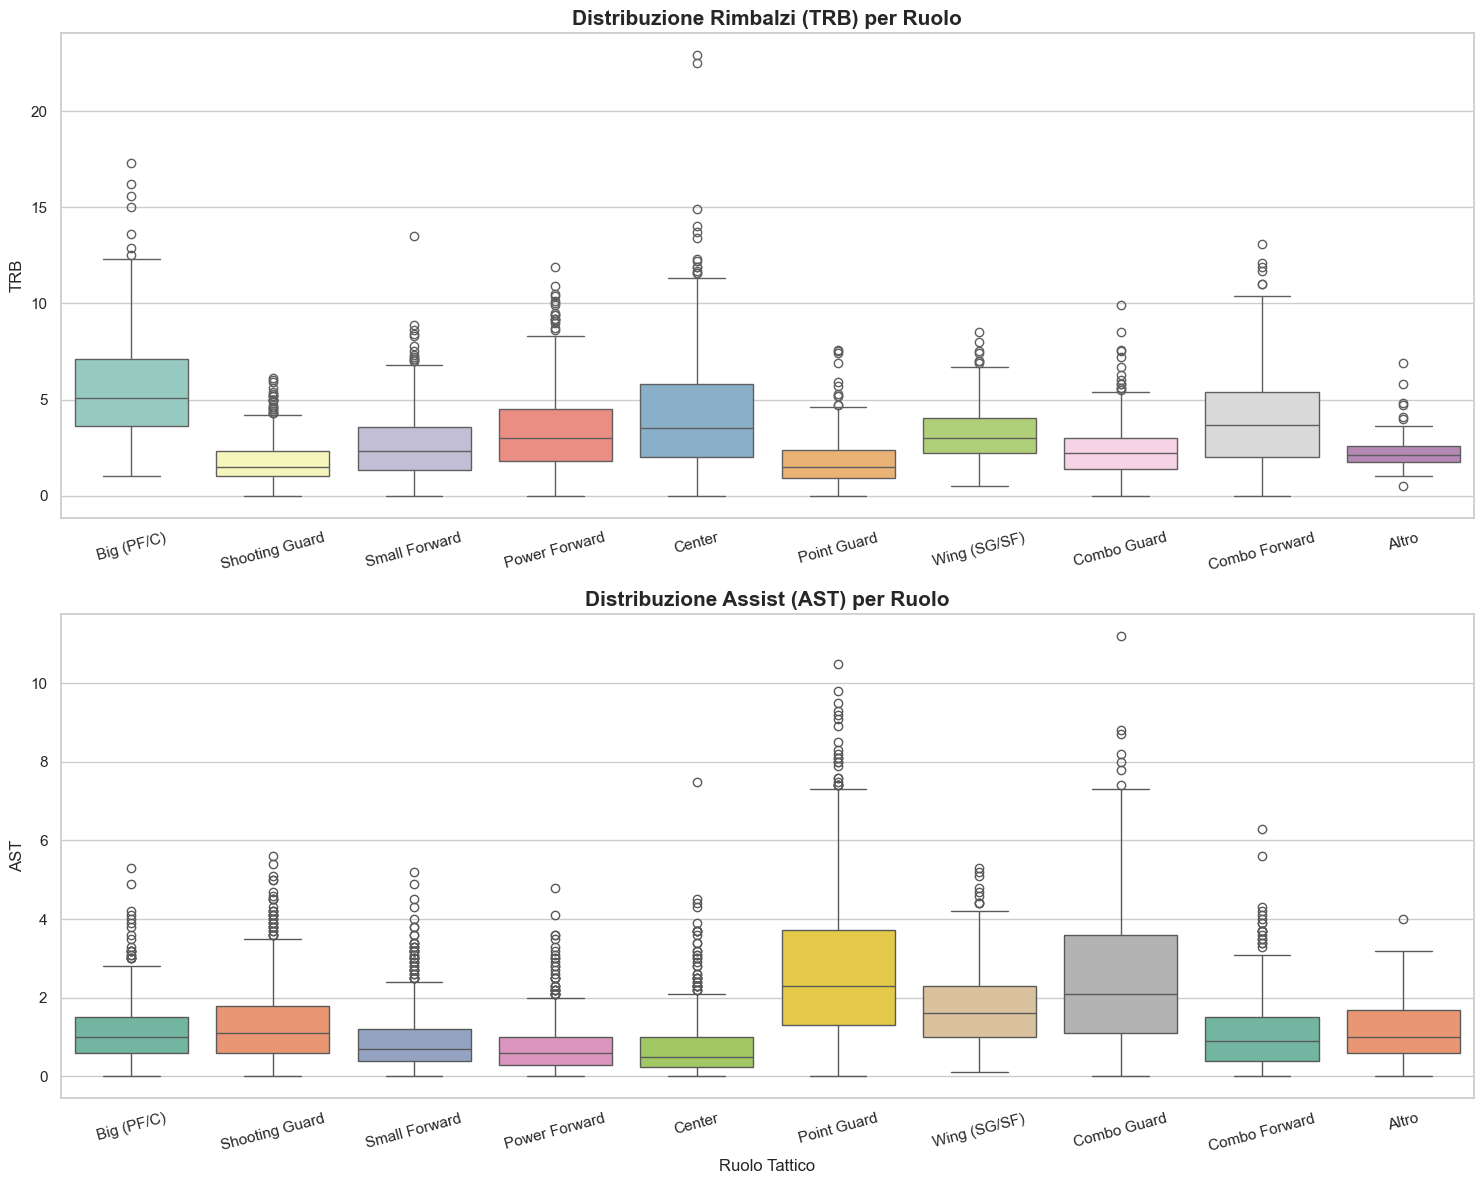

In [ ]:
df['TRB'] = pd.to_numeric(df['TRB'], errors='coerce')
df['AST'] = pd.to_numeric(df['AST'], errors='coerce')

if 'Ruolo_Specifico' not in df.columns:
    print("⚠️ Colonna 'Ruolo_Specifico' non trovata. Esegui prima il mapping dei ruoli.")
else:
    # figura con due Boxplot
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))

    # Boxplot 1: RIMBALZI (TRB)
    sns.boxplot(data=df, x='Ruolo_Specifico', y='TRB', hue='Ruolo_Specifico', palette='Set3', legend=False, ax=axes[0])
    axes[0].set_title("Distribuzione Rimbalzi (TRB) per Ruolo", fontsize=15, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].set_xlabel("")

    # Boxplot 2: ASSIST (AST)
    sns.boxplot(data=df, x='Ruolo_Specifico', y='AST', hue='Ruolo_Specifico', palette='Set2', legend=False, ax=axes[1])
    axes[1].set_title("Distribuzione Assist (AST) per Ruolo", fontsize=15, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].set_xlabel("Ruolo Tattico")

    plt.tight_layout()
    plt.show()